In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

def _slug(s: str) -> str:
    return "".join(c if c.isalnum() else "_" for c in s).strip("_").lower()

path_root = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'ensemble', 'pft1')

df = pd.read_csv(os.path.join(path_root, 'combined_cdr.csv'), index_col = 0)  # replace with your actual path
X = df.iloc[:, :4]  # Columns B-E: input variables
Y = df.iloc[:, 4:]   # Columns F-end: output variables: g CDR year-1

pmr = pd.read_csv(os.path.join(path_root, 'combined_pmr.csv'), index_col = 0)
pmr = pmr.iloc[:, 4:]  # g basalt year-1

model_to_average = ['Gradient Boosting', 'Random Forest']
y_pred = 0
for model in model_to_average:
    y_pred_A = pd.read_csv(os.path.join(path_root, f'predictions_{_slug(model)}.csv'), index_col = 0)
    y_pred = y_pred + y_pred_A
y_pred = y_pred / len(model_to_average)

# Mask the true values to where predicted values exist
mask = y_pred.isna().iloc[:,0].values
y_pred = y_pred.loc[~mask,:].clip(lower = 0)
pmr = pmr.loc[~mask,:]
Y = Y.loc[~mask,:].clip(lower = 0)

importances = pd.read_csv(os.path.join(path_root, "model_importances_random_forest.csv"))

performance = pd.read_csv(os.path.join(path_root, 'model_performance.csv'), index_col = [0, 1])

Grain size (um)       2
Rate (kg/m2)         10
Start year         2025
Frequency             9
Name: 453, dtype: int64


Text(0.5, 0, 'Ensemble ID')

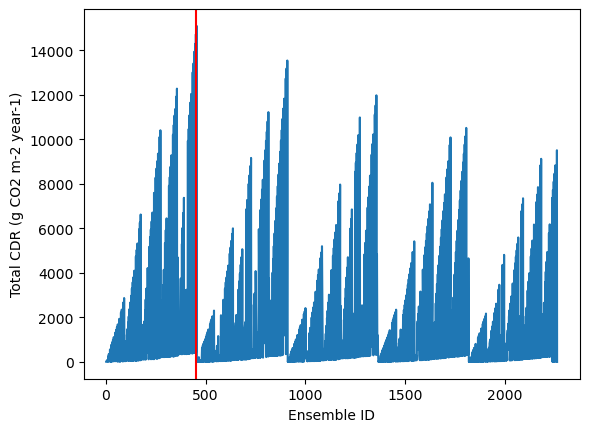

In [2]:
fig, ax = plt.subplots()
Y.mean(axis = 1).plot(ax = ax)
ax.axvline(453, color = 'r')
print(X.loc[453])
ax.set_ylabel('Total CDR (g CO2 m-2 year-1)')
ax.set_xlabel('Ensemble ID')

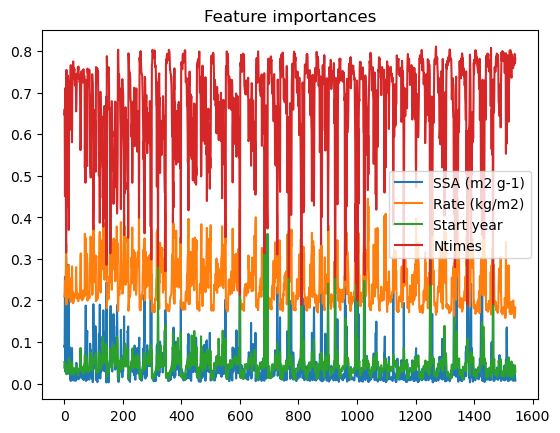

In [3]:
# Plot the feature importances from random forest
if model == "Random Forest":
    importances.plot()
    plt.title('Feature importances')

Text(0.5, 0.98, 'Total CDR (g m-2 year-1)')

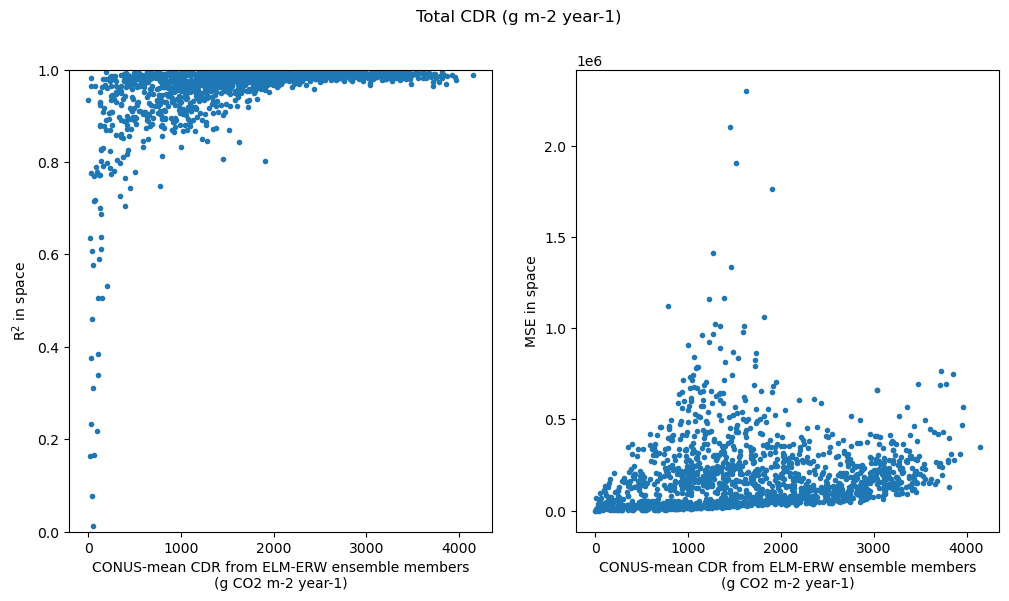

In [4]:
# Plot the relationship between simulated total CDR and prediction error (R2)
# --- based on the mean CONUS CDR
fig, axes = plt.subplots(1, 2, figsize = (12, 6))

ax = axes.flat[0]
ax.plot(Y.mean(axis = 0), performance.loc[model, 'R2'], 'o', markersize = 3)
ax.set_ylim([0, 1])
ax.set_ylabel('R$^2$ in space')
ax.set_xlabel('CONUS-mean CDR from ELM-ERW ensemble members\n(g CO2 m-2 year-1)')

ax = axes.flat[1]
ax.plot(Y.mean(axis = 0), performance.loc['Random Forest', 'MSE'], 'o', markersize = 3)
ax.set_ylabel('MSE in space')
ax.set_xlabel('CONUS-mean CDR from ELM-ERW ensemble members\n(g CO2 m-2 year-1)')

fig.suptitle('Total CDR (g m-2 year-1)')

Text(0.5, 0.98, 'Overall: R$^2$=0.87, $\\rho$=0.93, Mean bias=-0.00%')

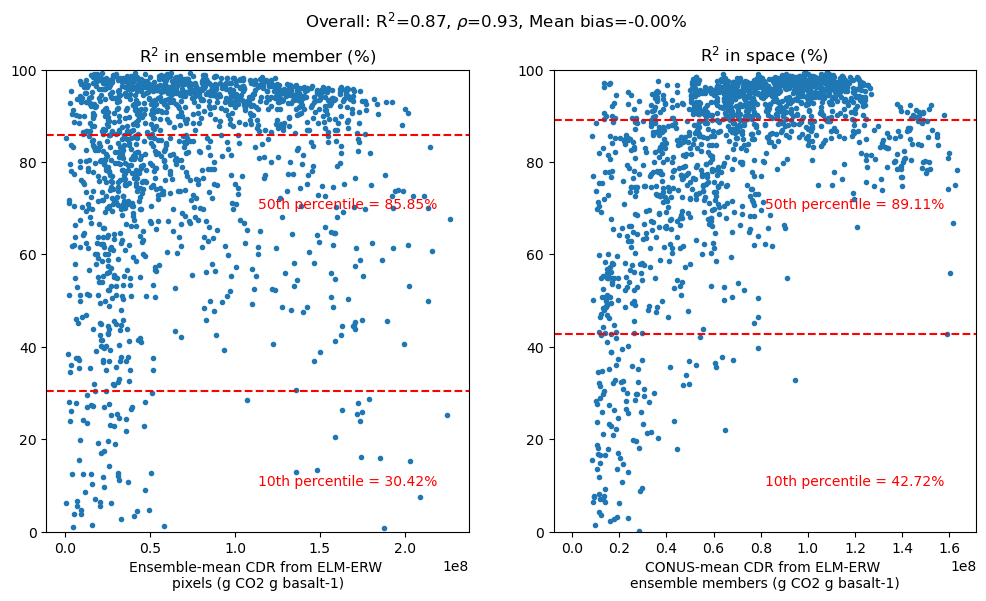

In [5]:
# Plot the relationship between simulated CDR rate and prediction error
# --- based on the mean CONUS CDR
y_rate = Y / pmr.values
y_pred_rate = y_pred / pmr.values

fig, axes = plt.subplots(1, 2, figsize = (12, 6))

ax = axes.flat[0]

#rel_MAE = (y_pred_rate - y_rate).abs().mean(axis = 0) / y_rate.mean(axis = 0) * 100.
rel_MAE = pd.Series({
    col: r2_score(y_pred_rate[col].dropna(), y_rate[col].dropna()) for col in y_pred_rate.columns
}) * 100.
pct_err = np.nanpercentile(rel_MAE, 10)
pct_err_50 = np.nanpercentile(rel_MAE, 50)

ax.plot(y_rate.mean(axis = 0), rel_MAE, 'o', markersize = 3)
ax.axhline(pct_err, ls = '--', color = 'r')
ax.text(0.5, 0.1, f'10th percentile = {pct_err:.2f}%', 
        color = 'r', transform = ax.transAxes)
ax.axhline(pct_err_50, ls = '--', color = 'r')
ax.text(0.5, 0.7, f'50th percentile = {pct_err_50:.2f}%', 
        color = 'r', transform = ax.transAxes)
ax.set_xlabel('Ensemble-mean CDR from ELM-ERW \npixels (g CO2 g basalt-1)')
ax.set_title('R$^2$ in ensemble member (%)')
ax.set_ylim([0,100])

ax = axes.flat[1]

#rel_MAE = (y_pred_rate - y_rate).abs().mean(axis = 1) / y_rate.mean(axis = 1) * 100.
rel_MAE = pd.Series({
    ind: r2_score(y_pred_rate.loc[ind].dropna(), y_rate.loc[ind].dropna()) for ind in y_pred_rate.index
}) * 100.
pct_err = np.nanpercentile(rel_MAE, 10)
pct_err_50 = np.nanpercentile(rel_MAE, 50)

ax.plot(y_rate.mean(axis = 1), rel_MAE, 'o', markersize = 3)
ax.axhline(pct_err, ls = '--', color = 'r')
ax.text(0.5, 0.1, f'10th percentile = {pct_err:.2f}%', 
        color = 'r', transform = ax.transAxes)
ax.axhline(pct_err_50, ls = '--', color = 'r')
ax.text(0.5, 0.7, f'50th percentile = {pct_err_50:.2f}%', 
        color = 'r', transform = ax.transAxes)
ax.set_xlabel('CONUS-mean CDR from ELM-ERW \nensemble members (g CO2 g basalt-1)')
ax.set_title('R$^2$ in space (%)')
ax.set_ylim([0,100])

#
x = y_rate.values.reshape(-1)
y = y_pred_rate.values.reshape(-1)
overall_r2 = r2_score(x, y)
rho, pval = pearsonr(x, y)
bias = np.mean(x-y) / np.mean(x)
fig.suptitle('Overall: R$^2$=' + f'{overall_r2:0.2f}, ' + r'$\rho$=' + f'{rho:0.2f}, Mean bias={bias:0.2f}%')

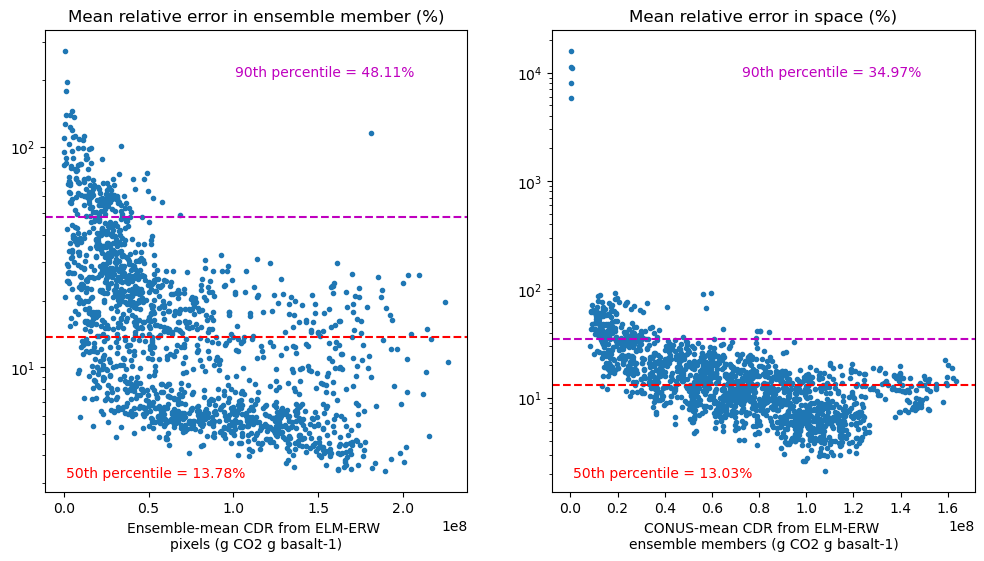

In [6]:
# Plot the relationship between simulated CDR rate and prediction error
# --- based on the mean CONUS CDR
y_rate = Y / pmr.values
y_pred_rate = y_pred / pmr.values

fig, axes = plt.subplots(1, 2, figsize = (12, 6))

ax = axes.flat[0]

rel_MAE = (y_pred_rate - y_rate).abs().mean(axis = 0) / y_rate.abs().mean(axis = 0) * 100.
pct_err_50 = np.nanpercentile(rel_MAE, 50)
pct_err_90 = np.nanpercentile(rel_MAE, 90)

ax.plot(y_rate.mean(axis = 0), rel_MAE, 'o', markersize = 3)
ax.axhline(pct_err_50, ls = '--', color = 'r')
ax.axhline(pct_err_90, ls = '--', color = 'm')
ax.text(0.05, 0.03, f'50th percentile = {pct_err_50:.2f}%', 
        color = 'r', transform = ax.transAxes)
ax.text(0.45, 0.9, f'90th percentile = {pct_err_90:.2f}%', 
        color = 'm', transform = ax.transAxes)
ax.set_xlabel('Ensemble-mean CDR from ELM-ERW \npixels (g CO2 g basalt-1)')
ax.set_title('Mean relative error in ensemble member (%)')
ax.set_yscale('log')

ax = axes.flat[1]

rel_MAE = (y_pred_rate - y_rate).abs().mean(axis = 1) / y_rate.abs().mean(axis = 1) * 100.
pct_err_50 = np.nanpercentile(rel_MAE, 50)
pct_err_90 = np.nanpercentile(rel_MAE, 90)

ax.plot(y_rate.mean(axis = 1), rel_MAE, 'o', markersize = 3)
ax.axhline(pct_err_50, ls = '--', color = 'r')
ax.axhline(pct_err_90, ls = '--', color = 'm')
ax.text(0.05, 0.03, f'50th percentile = {pct_err_50:.2f}%', 
        color = 'r', transform = ax.transAxes)
ax.text(0.45, 0.9, f'90th percentile = {pct_err_90:.2f}%', 
        color = 'm', transform = ax.transAxes)
ax.set_xlabel('CONUS-mean CDR from ELM-ERW \nensemble members (g CO2 g basalt-1)')
ax.set_title('Mean relative error in space (%)')
ax.set_yscale('log')

(-100.0, 100.0)

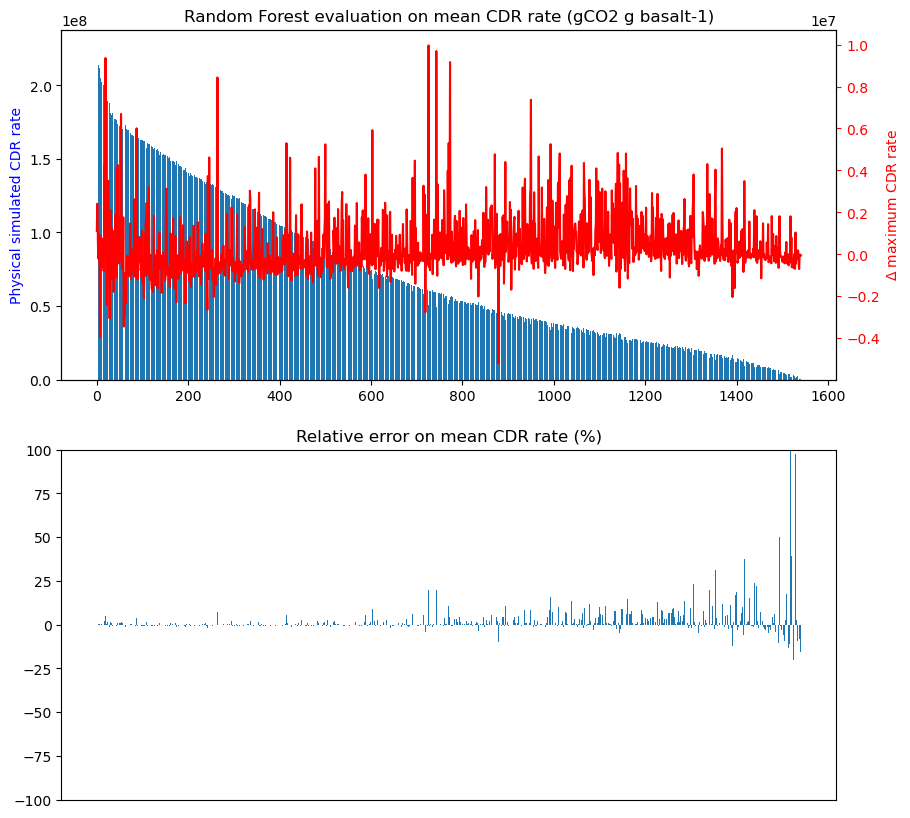

In [7]:
# Compuate the difference between the ML-predicted and physical model-simulated mean CDR rate 
# (per g basalt basis)

# ---- convert to per g basalt
y_pred_masked = y_pred / pmr.values
Y_masked = Y / pmr.values

# Read the maximum CDR from both
y_pred_max = y_pred_masked.mean(axis = 0)
y_max = Y_masked.mean(axis = 0)

# The error in mean CDR
err_in_max = y_pred_max - y_max

# CDR High -> Low index
re_idx = y_pred_max.sort_values(ascending=False).index

#
x = np.arange(len(re_idx))
fig, axes = plt.subplots(2, 1, figsize = (10, 10))

ax = axes.flat[0]

ax.bar(x, height = y_max.loc[re_idx])
ax.set_ylabel('Physical simulated CDR rate', color = 'b')
#ax.set_xticks([])
ax.set_title(f'{model} evaluation on mean CDR rate (gCO2 g basalt-1)')

ax2 = ax.twinx()
ax2.plot(x, err_in_max.loc[re_idx], '-r')
ax2.yaxis.set_tick_params('major', color = 'r')
for label in ax2.get_yticklabels():
    label.set_color('r')
ax2.set_ylabel('$\Delta$ maximum CDR rate', color = 'r')
ax.set_title(f'{model} evaluation on mean CDR rate (gCO2 g basalt-1)')

ax = axes.flat[1]

ax.bar(x, height = err_in_max.loc[re_idx] / y_max.loc[re_idx] * 100)
ax.set_title('Relative error on mean CDR rate (%)')
ax.set_xticks([])
ax.set_ylim([-100, 100])

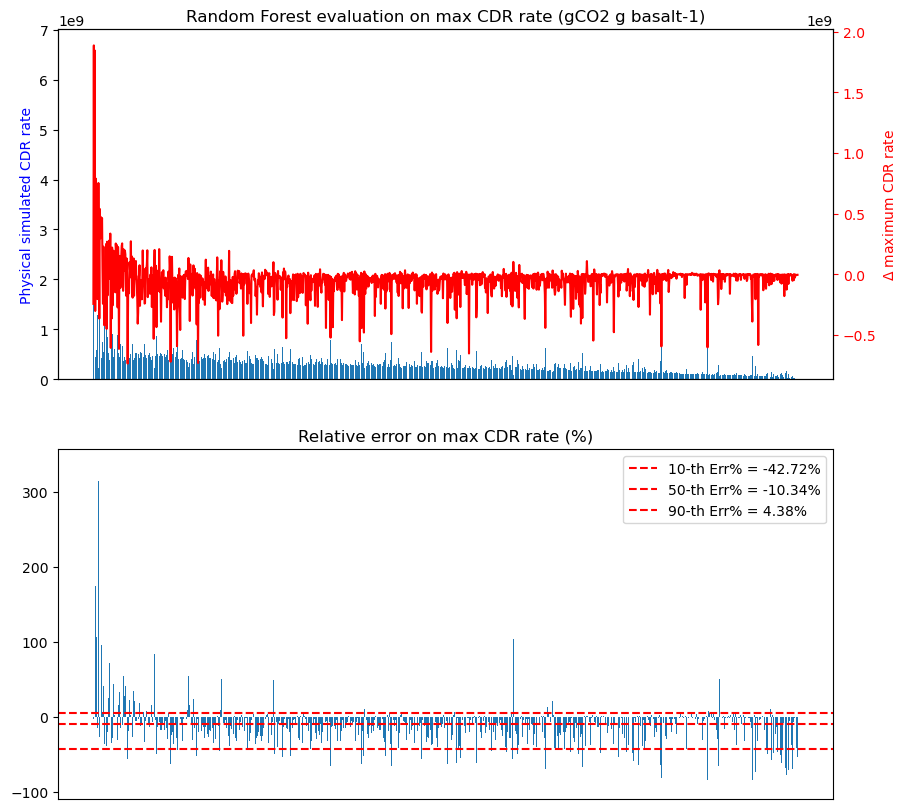

In [8]:
# Compuate the difference between the ML-predicted and physical model-simulated maximum CDR rate 
# (per g basalt basis)

# Mask the true values to where predicted values exist
mask = y_pred.isna().iloc[:,0]
# ---- convert to per g basalt
y_pred_masked = y_pred.loc[~mask,:] / pmr.loc[~mask,:].values
Y_masked = Y.loc[~mask,:] / pmr.loc[~mask,:].values

# Read the maximum CDR from both
y_pred_max = y_pred_masked.max(axis = 0)
y_max = Y_masked.max(axis = 0)

# The error in maximum CDR
err_in_max = y_pred_max - y_max

# CDR High -> Low index
re_idx = y_pred_max.sort_values(ascending=False).index

#
x = np.arange(len(re_idx))
fig, axes = plt.subplots(2, 1, figsize = (10, 10))

ax = axes.flat[0]

ax.bar(x, height = y_max.loc[re_idx])
ax.set_ylabel('Physical simulated CDR rate', color = 'b')
ax.set_xticks([])
ax.set_title(f'{model} evaluation on max CDR rate (gCO2 g basalt-1)')
ax.set_title(f'{model} evaluation on max CDR rate (gCO2 g basalt-1)')

ax2 = ax.twinx()
ax2.plot(x, err_in_max.loc[re_idx], '-r')
ax2.yaxis.set_tick_params('major', color = 'r')
for label in ax2.get_yticklabels():
    label.set_color('r')
ax2.set_ylabel('$\Delta$ maximum CDR rate', color = 'r')

ax = axes.flat[1]

rel_err = err_in_max.loc[re_idx] / y_max.loc[re_idx] * 100

ax.bar(x, rel_err)
ax.set_title('Relative error on max CDR rate (%)')
ax.set_xticks([])

err = np.nanpercentile(rel_err, 10)
ax.axhline(err, ls = '--', color = 'r', label = f'10-th Err% = {err:.2f}%')
err = np.nanpercentile(rel_err, 50)
ax.axhline(err, ls = '--', color = 'r', label = f'50-th Err% = {err:.2f}%')
err = np.nanpercentile(rel_err, 90)
ax.axhline(err, ls = '--', color = 'r', label = f'90-th Err% = {err:.2f}%')
ax.legend()

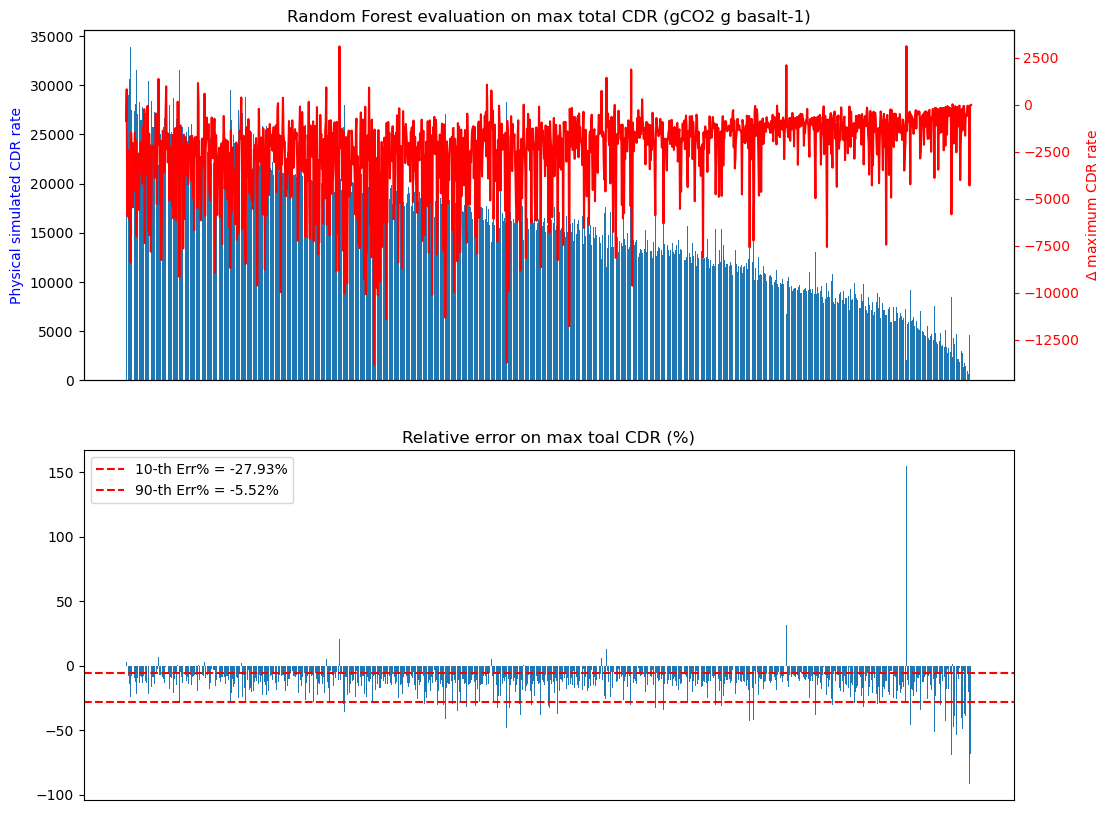

In [9]:
# Compuate the difference between the ML-predicted and physical model-simulated maximum total CDR 
# (per m2 basis)

# Calculate the total applied basalt
ntimes = X.apply(
        lambda df: len(np.arange(df['Start year'], 2050 + 1, df['Frequency'])),
        axis = 1
    )
total_basalt = X['Rate (kg/m2)'] * ntimes * 1000.

# Mask the true values to where predicted values exist
mask = y_pred.isna().iloc[:, 0]

y_pred_masked = y_pred.loc[~mask, :]
Y_masked = Y.loc[~mask, :]

# Read the maximum CDR from both
y_pred_max = y_pred_masked.max(axis = 0)
y_max = Y_masked.max(axis = 0)

# The error in mean CDR
err_in_max = y_pred_max - y_max

# CDR High -> Low index
re_idx = y_pred_max.sort_values(ascending=False).index

#
x = np.arange(len(re_idx))
fig, axes = plt.subplots(2, 1, figsize = (12, 10))

ax = axes.flat[0]

ax.bar(x, height = y_max.loc[re_idx])
ax.set_ylabel('Physical simulated CDR rate', color = 'b')
ax.set_xticks([])
ax.set_title(f'{model} evaluation on max total CDR (gCO2 g basalt-1)')

ax2 = ax.twinx()
ax2.plot(x, err_in_max.loc[re_idx], '-r')
ax2.yaxis.set_tick_params('major', color = 'r')
for label in ax2.get_yticklabels():
    label.set_color('r')
ax2.set_ylabel('$\Delta$ maximum CDR rate', color = 'r')
ax.set_title(f'{model} evaluation on max total CDR (gCO2 g basalt-1)')

ax = axes.flat[1]

rel_err = height = err_in_max.loc[re_idx] / y_max.loc[re_idx] * 100

ax.bar(x, rel_err)
ax.set_title('Relative error on max toal CDR (%)')
ax.set_xticks([])

err = np.nanpercentile(rel_err, 10)
ax.axhline(err, ls = '--', color = 'r', label = f'10-th Err% = {err:.2f}%')
err = np.nanpercentile(rel_err, 90)
ax.axhline(err, ls = '--', color = 'r', label = f'90-th Err% = {err:.2f}%')
ax.legend()